In [1]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.models import efficientnet_v2_s
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


In [2]:
TRAIN_PATH = "/kaggle/input/knee-osteoarthritis-dataset-with-class-balance/Knee Osteoarthritis Dataset/train"
TEST_PATH  = "/kaggle/input/knee-osteoarthritis-dataset-with-class-balance/Knee Osteoarthritis Dataset/test"

BEST_MODEL_PATH = "/kaggle/working/best_effnetv2s_msccm.pth"

class_names = ["Healthy", "Doubtful", "Minimal", "Moderate", "Severe"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [3]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(7),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [4]:
train_dataset = datasets.ImageFolder(TRAIN_PATH, transform=train_transform)
test_dataset  = datasets.ImageFolder(TEST_PATH, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

print("Train samples:", len(train_dataset))
print("Test samples :", len(test_dataset))


Train samples: 8000
Test samples : 2000


In [5]:
class MSCCM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 1)
        self.conv3 = nn.Conv2d(channels, channels, 3, padding=1)
        self.conv5 = nn.Conv2d(channels, channels, 5, padding=2)
        self.relu = nn.ReLU(inplace=True)

        self.fc1 = nn.Linear(channels, channels // reduction)
        self.fc2 = nn.Linear(channels // reduction, channels)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.conv1(x) + self.conv3(x) + self.conv5(x))
        b, c, _, _ = x.size()
        gap = torch.mean(x, dim=[2, 3])
        attn = self.sigmoid(self.fc2(self.relu(self.fc1(gap)))).view(b, c, 1, 1)
        return x * attn


In [6]:
class EfficientNetV2S_MSCCM(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        base = efficientnet_v2_s(weights="IMAGENET1K_V1")

        self.features = base.features
        self.msccm = MSCCM(channels=160)   # ✅ correct stage
        self.pool = base.avgpool
        self.classifier = nn.Linear(1280, num_classes)

    def forward(self, x):
        msccm_used = False   # reset every forward pass

        for block in self.features:
            x = block(x)

            # ✅ ATTENTION IS APPLIED HERE (ONCE)
            if (not msccm_used) and x.shape[1] == 160:
                x = self.msccm(x)
                msccm_used = True

        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


In [7]:
model = EfficientNetV2S_MSCCM().to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)


Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 182MB/s] 


In [8]:
def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)

            total_loss += loss.item()
            preds = torch.argmax(out, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    return total_loss / len(loader), correct / total, all_preds, all_labels


In [9]:
EPOCHS = 25
train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_acc = 0
start_time = time.time()

for epoch in range(EPOCHS):
    model.train()
    tr_loss, tr_correct, tr_total = 0, 0, 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        tr_loss += loss.item()
        preds = torch.argmax(out, dim=1)
        tr_correct += (preds == y).sum().item()
        tr_total += y.size(0)

    train_loss = tr_loss / len(train_loader)
    train_acc = tr_correct / tr_total

    val_loss, val_acc, _, _ = evaluate(model, test_loader)
    scheduler.step(val_acc)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)

    lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] | "
        f"LR: {lr:.6f} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc*100:.2f}% | "
        f"Best Val Acc: {best_val_acc*100:.2f}%"
    )


Epoch [01/25] | LR: 0.000300 | Train Loss: 1.0540 | Train Acc: 58.21% | Val Loss: 0.8548 | Val Acc: 69.05% | Best Val Acc: 69.05%
Epoch [02/25] | LR: 0.000300 | Train Loss: 0.8511 | Train Acc: 68.91% | Val Loss: 0.7670 | Val Acc: 72.75% | Best Val Acc: 72.75%
Epoch [03/25] | LR: 0.000300 | Train Loss: 0.7849 | Train Acc: 72.05% | Val Loss: 0.7987 | Val Acc: 70.60% | Best Val Acc: 72.75%
Epoch [04/25] | LR: 0.000300 | Train Loss: 0.7460 | Train Acc: 74.08% | Val Loss: 0.7540 | Val Acc: 72.95% | Best Val Acc: 72.95%
Epoch [05/25] | LR: 0.000300 | Train Loss: 0.7201 | Train Acc: 75.26% | Val Loss: 0.7632 | Val Acc: 73.85% | Best Val Acc: 73.85%
Epoch [06/25] | LR: 0.000300 | Train Loss: 0.7036 | Train Acc: 76.34% | Val Loss: 0.7358 | Val Acc: 75.80% | Best Val Acc: 75.80%
Epoch [07/25] | LR: 0.000300 | Train Loss: 0.6739 | Train Acc: 77.86% | Val Loss: 0.6893 | Val Acc: 77.80% | Best Val Acc: 77.80%
Epoch [08/25] | LR: 0.000300 | Train Loss: 0.6606 | Train Acc: 78.36% | Val Loss: 0.7083 |

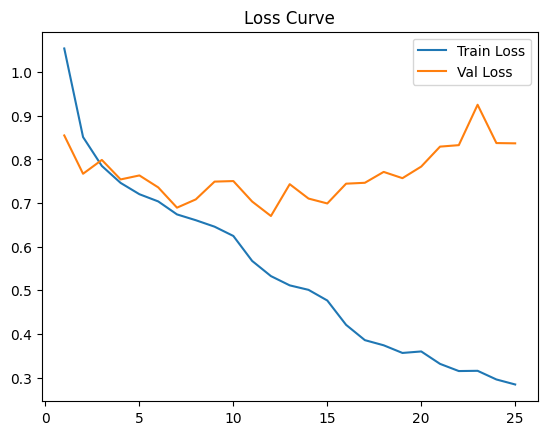

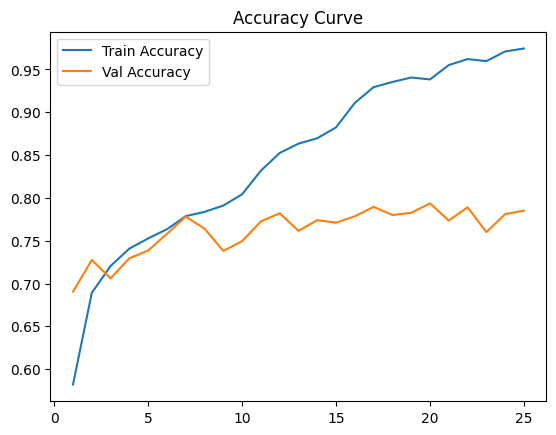

In [10]:
epochs = range(1, EPOCHS + 1)

plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.figure()
plt.plot(epochs, train_accs, label="Train Accuracy")
plt.plot(epochs, val_accs, label="Val Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.show()



🎯 FINAL TEST ACCURACY: 79.35%


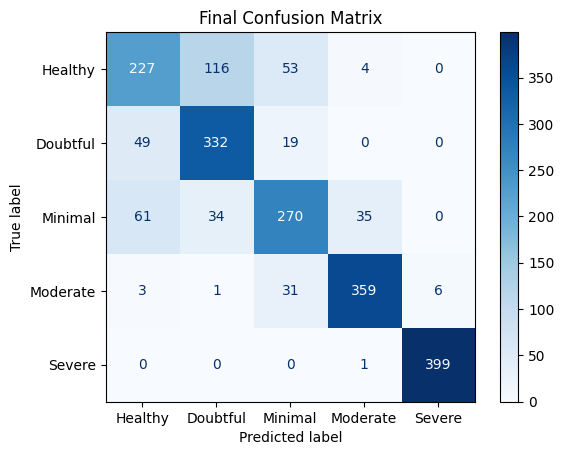

In [ ]:
model.load_state_dict(torch.load(BEST_MODEL_PATH))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        preds = torch.argmax(out, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

test_acc = accuracy_score(all_labels, all_preds)
print(f"\n🎯 FINAL TEST ACCURACY: {test_acc*100:.2f}%")

cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap="Blues")
plt.title("Final Confusion Matrix")
plt.show()
